# Trabajo Práctico N°7 del TPS: PCA, K-means y EM

En este trabajo práctico se implementa un algoritmo de PCA condicional para aprender una curva representativa de un *manifold* 2D no lineal. La idea es combinar un algoritmo de clustering (K-Means y luego EM) con un PCA por cluster, de manera que cada cluster aproxime localmente una recta del manifold. Finalmente, se utiliza el error de reconstrucción del PCA como detector de anomalías.



Se importan las librerías que se utilizarán a lo largo del mismo.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Inciso A: Creación del *dataset*



El objetivo de este inciso es generar datos sintéticos que simulen mediciones ruidosas de una curva en el plano. La curva subyacente (el manifold) es un triángulo formado por tres segmentos de recta, definido por la función $g(u)$ para $u \in [0, 1]$.

La curva subyacente se llama manifold: es una curva parametrizada $g(u)$ con $u \in [0,1]$, exactamente igual a las parametrizaciones de Análisis II. Con un solo parámetro $u$ se puede ubicar cualquier punto de la curva, aunque esa curva viva en $\mathbb{R}^2$. En este caso, $g(u)$ traza un triángulo, sube en diagonal, baja en diagonal, y vuelve horizontalmente al origen.

Para generar los datos se realiza una simulación de Monte Carlo con dos fuentes de aleatoriedad:
- $U_i \sim \mathcal{U}(0,1)$: elige un punto al azar a lo largo de la curva.
- $Z_i \sim \mathcal{N}(0, I)$: agrega ruido gaussiano en todas las direcciones, simulando error de medición.

El resultado es una nube de 200 puntos distribuidos cerca del triángulo. El objetivo de todo el TP es que los algoritmos recuperen ese triángulo a partir de los datos, sin saber de antemano que es un triángulo.

In [2]:
np.random.seed(42)

N = 200

# Sortear U_i ~ Uniform(0,1)
U = np.random.uniform(0, 1, N)

# Evaluar g(u) — tres tramos lineales
def g(u):
    x = np.where(u < 1/3,  1.5 * u,
        np.where(u < 2/3,  1.5 * u,
                            3 - 3 * u))
    y = np.where(u < 1/3,  3 * u,
        np.where(u < 2/3,  2 - 3 * u,
                            np.zeros_like(u)))
    return np.column_stack([x, y])

G = g(U)

# Ruido gaussiano estándar bivariado
Z = np.random.randn(N, 2)

X = G + 0.05 * Z

Se grafica el *scatter* y el *mainfold* en el mismo plano.

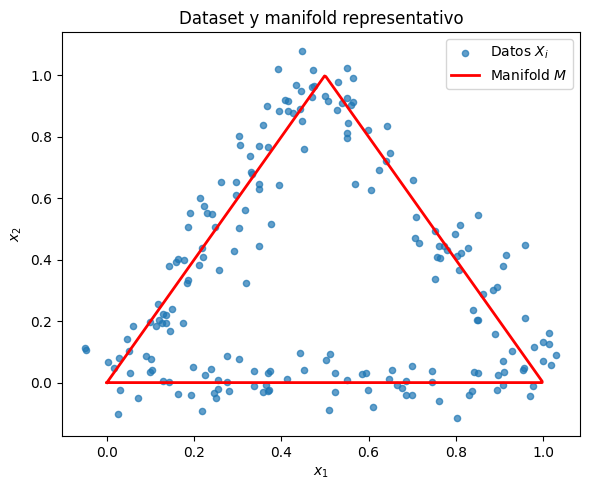

In [3]:
# Curva representativa del manifold (sin ruido)
u_curve = np.linspace(0, 1, 500)
M = g(u_curve)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X[:, 0], X[:, 1], s=20, alpha=0.7, label='Datos $X_i$')
ax.plot(M[:, 0], M[:, 1], color='red', linewidth=2, label='Manifold $M$')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('Dataset y manifold representativo')
ax.legend()
plt.tight_layout()
plt.show()

El gráfico muestra lo esperado: los 200 puntos forman tres nubes alargadas, una por cada lado del triángulo, y la curva roja pasa por el centro de cada nube. El ruido es pequeño pero visible. Hay dispersión perpendicular a cada lado, simulando correctamente el error de medición.

A partir de esta visualización se puede anticipar el comportamiento de los algoritmos de clustering:

- **K-Means:** agrupa por distancia al centroide, asumiendo clusters circulares (isótropos). Esto puede ser problemático acá porque los tres grupos son claramente alargados y orientados en distintas direcciones. En las esquinas del triángulo, donde se juntan puntos de dos lados distintos, K-Means puede cometer errores de asignación.
- **EM:** modela cada cluster con una Gaussiana completa (con covarianza), por lo que puede capturar la forma alargada de cada lado. Se espera que encuentre los tres grupos con mayor precisión.

## Inciso B: K-Means

Se implementa el algoritmo K-Means para clusterizar los datos. El primer paso es elegir $K$, la cantidad de clusters.

En la práctica, $K$ no se conoce de antemano. Las estrategias habituales son probar varios valores y usar métricas como el método del codo (graficar la inercia en función de $K$ y buscar el punto donde la mejora se vuelve marginal) o el silhouette score (qué tan bien separado está cada punto de los clusters vecinos). Es análogo a elegir el orden de un filtro en telecomunicaciones: probás distintos órdenes y buscás el punto donde agregar más no mejora significativamente la respuesta.

En este caso se usa conocimiento del dominio: el manifold tiene 3 lados, por lo que $K = 3$ es la elección natural. En telecomunicaciones sería como saber de antemano cuántas fuentes de señal hay. Cada cluster debería capturar un lado del triángulo.

### Implementación

La clase `KMeans` se construye con la misma estructura que en el TP6: inicialización aleatoria de centroides, reasignación por distancia euclidiana y actualización iterativa hasta convergencia.

Los hiperparámetros son:
- `max_iter=300`: cota de seguridad para que el algoritmo no corra indefinidamente si no converge. En la práctica K-Means converge en pocas iteraciones para datasets chicos.
- `tol=1e-4`: el algoritmo se detiene cuando el desplazamiento de los centroides entre iteraciones es menor a este umbral. Es el criterio de convergencia.
- `random_state=0`: fija la semilla de inicialización para reproducibilidad. En general, se recomienda correr K-Means varias veces con distintas semillas y quedarse con la solución de menor inercia, ya que la inicialización aleatoria puede llevar a óptimos locales. En este caso, sin embargo, no vale la pena: como se anticipó en el análisis del inciso A, el problema no es la inicialización sino la suposición estructural del modelo: K-Means asume clusters esféricos, y los datos tienen forma alargada. Ninguna inicialización va a corregir ese desajuste estructural.

In [4]:
class KMeans:
    def __init__(self, k=3, max_iter=300, tol=1e-4, random_state=0):
        self.k = k
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.centroids = None
        self.n_iter_ = None

    def fit(self, X):
        rng = np.random.default_rng(self.random_state)
        idx = rng.choice(len(X), self.k, replace=False)
        self.centroids = X[idx].astype(float).copy()

        for it in range(self.max_iter):
            labels = self._assign(X)

            new_centroids = np.array([
                X[labels == j].mean(axis=0) if np.any(labels == j)
                else self.centroids[j]
                for j in range(self.k)
            ])

            shift = np.max(np.linalg.norm(new_centroids - self.centroids, axis=1))
            self.centroids = new_centroids

            if shift < self.tol:
                self.n_iter_ = it + 1
                print(f'Convergió en {self.n_iter_} iteraciones (shift = {shift:.2e})')
                break
        else:
            self.n_iter_ = self.max_iter
            print(f'Máximo de iteraciones alcanzado ({self.max_iter})')

    def _assign(self, X):
        dists = np.linalg.norm(X[:, None, :] - self.centroids[None, :, :], axis=2)
        return np.argmin(dists, axis=1)

    def predict(self, X):
        return self._assign(X)

### Entrenamiento y visualización

Convergió en 5 iteraciones (shift = 0.00e+00)


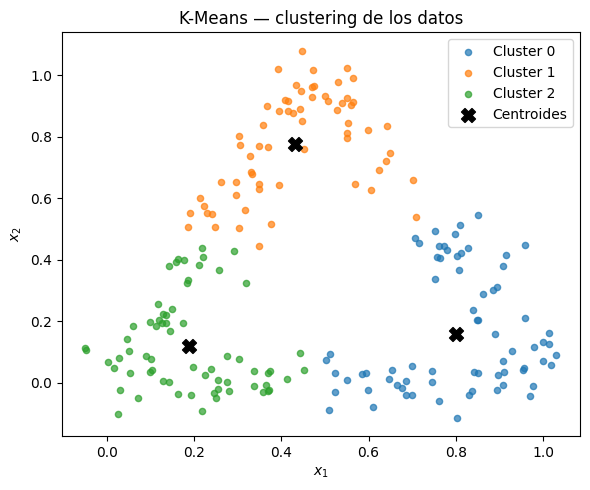

In [5]:
km = KMeans(k=3)
km.fit(X)
labels_km = km.predict(X)

colors = ['tab:blue', 'tab:orange', 'tab:green']

fig, ax = plt.subplots(figsize=(6, 5))
for j in range(km.k):
    mask = labels_km == j
    ax.scatter(X[mask, 0], X[mask, 1], s=20, alpha=0.7, color=colors[j], label=f'Cluster {j}')
ax.scatter(km.centroids[:, 0], km.centroids[:, 1], s=100, marker='X', color='black', zorder=5, label='Centroides')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('K-Means — clustering de los datos')
ax.legend()
plt.tight_layout()
plt.show()

El algoritmo convergió en solo 5 iteraciones.

El gráfico valida la hipótesis planteada en el inciso A: los tres clusters recuperan aproximadamente los tres lados del triángulo, pero aparecen errores sistemáticos en las esquinas, donde puntos de un lado quedan asignados al cluster del lado adyacente. Esto es exactamente lo que se esperaba: K-Means asigna cada punto al centroide más cercano en distancia euclidiana, asumiendo implícitamente que los clusters son esféricos e isótropos. Los lados del triángulo son estructuras alargadas y orientadas, no círculos, por lo tanto K-Means no es el modelo adecuado para esta geometría.

### ¿Es suficiente K-Means para esta tarea?

**No.** K-Means agrupa por proximidad al centroide sin considerar la orientación ni la forma de los clusters. En las esquinas del triángulo, un punto puede estar más cerca del centroide del lado adyacente que del centroide de su propio lado, simplemente porque los centroides quedan en el medio de cada lado. Esto genera errores de asignación sistemáticos en las zonas de transición entre segmentos.

Para capturar correctamente la geometría alargada de cada lado se necesita un modelo que modele también la covarianza de cada cluster, es decir, el algoritmo EM con mezclas de Gaussianas.

## Inciso C: Algoritmo Expectation-Maximization (EM)


K-Means no fue suficiente porque asume que todos los clusters son esféricos: le fija la covarianza a la identidad y solo aprende el centro de cada grupo. Pero los datos tienen forma alargada: cada lado del triángulo es una nube orientada en una dirección, no un círculo. Ninguna inicialización ni ningún ajuste de K-Means puede corregir eso, porque el problema es estructural del modelo.

Para resolverlo se necesita un algoritmo que aprenda también la forma de cada cluster, no solo su centro. Ese algoritmo es **EM** (*Expectation-Maximization*), y el modelo subyacente es una mezcla de gaussianas.

### El modelo: mezcla de gaussianas

La idea es asumir que los datos fueron generados por $K$ fuentes gaussianas mezcladas. Cada fuente tiene:
- una **media** $\mu_k$: el centro del cluster,
- una **covarianza** $\Sigma_k$: la forma y orientación del cluster (libre, no fija),
- un **peso** $\pi_k$: qué fracción de los datos proviene de esa fuente.

A diferencia de K-Means, donde cada punto pertenece exactamente a un cluster, en el modelo de mezcla cada punto puede haber venido de cualquier fuente. Lo que se observa es el punto; de cuál fuente vino es una variable oculta que no se conoce.

### El problema del huevo y la gallina

Esto genera un dilema circular:
- Si se supiera de qué fuente vino cada punto, se podrían estimar fácilmente $\mu_k$, $\Sigma_k$ y $\pi_k$ como promedios ponderados.
- Si se conocieran $\mu_k$, $\Sigma_k$ y $\pi_k$, se podría calcular fácilmente la probabilidad de que cada punto venga de cada fuente.

EM resuelve este dilema alternando entre los dos pasos hasta converger.

### Expectation: ¿de dónde vino cada punto?

Dados los parámetros actuales, se calcula para cada punto $x_i$ la responsabilidad $r_{ik}$: qué tan probable es que haya venido de la fuente $k$. Esto es simplemente la regla de Bayes:

$$r_{ik} = \frac{\pi_k \, \mathcal{N}(x_i \mid \mu_k, \Sigma_k)}{\sum_{j=1}^{K} \pi_j \, \mathcal{N}(x_i \mid \mu_j, \Sigma_j)}$$

El numerador es la densidad de la gaussiana $k$ evaluada en $x_i$, pesada por la probabilidad a priori $\pi_k$ de esa fuente. El denominador normaliza para que las responsabilidades sumen 1. Un punto en la frontera entre dos clusters puede tener $r_{i1} = 0.6$ y $r_{i2} = 0.4$, por lo que pertenece parcialmente a ambos. Esto es lo que distingue a EM de K-Means: la asignación es blanda, no dura.

### Maximization: ¿cómo quedan los parámetros?

Dados los $r_{ik}$, se actualizan los parámetros como promedios ponderados donde el peso de cada punto en el cluster $k$ es su responsabilidad $r_{ik}$:

$$\mu_k = \frac{\sum_i r_{ik} \, x_i}{\sum_i r_{ik}}, \qquad \Sigma_k = \frac{\sum_i r_{ik} \, (x_i - \mu_k)(x_i - \mu_k)^T}{\sum_i r_{ik}}, \qquad \pi_k = \frac{\sum_i r_{ik}}{N}$$

La media es el centroide ponderado. La covarianza es la dispersión ponderada alrededor de ese centroide, si los puntos con alto $r_{ik}$ están distribuidos a lo largo de una recta, $\Sigma_k$ se estira en esa dirección. Los pesos $\pi_k$ reflejan cuántos puntos "pertenecen" a cada fuente.

### La convergencia

EM garantiza que la log-verosimilitud $\mathcal{L} = \sum_i \log p(x_i)$ nunca decrece entre iteraciones. Intuitivamente, esto mide qué tan bien el modelo explica los datos observados: una gaussiana estirada en la dirección de una nube alargada tiene mayor densidad sobre esos puntos que una esférica, por lo que contribuye más a $\mathcal{L}$. El algoritmo se detiene cuando la mejora entre iteraciones cae por debajo de un umbral `tol`.

### Comparación con K-Means

| | K-Means | EM |
|---|---|---|
| Forma del cluster | esférica (fija) | libre (aprende $\Sigma_k$) |
| Asignación de puntos | dura (un cluster) | blanda ($r_{ik} \in [0,1]$) |
| Parámetros | solo $\mu_k$ | $\mu_k$, $\Sigma_k$, $\pi_k$ |
| Criterio de convergencia | desplazamiento de centroides | log-verosimilitud |

K-Means es de hecho, a muy grandes rasgos y bajo ciertas condiciones, un caso límite de EM: si se fija $\Sigma_k = I$ para todo $k$ y se llevan las responsabilidades a 0 o 1 (asignación dura), se recupera exactamente el algoritmo K-Means.

### Implementación


Los hiperparámetros `max_iter=100` y `tol=1e-4` se mantienen consistentes con los TPs anteriores. Se redujo `max_iter` a 100 respecto del K-Means (que usó 300) porque cada iteración de EM es más costosa, implica calcular densidades gaussianas y actualizar covarianzas, y en la práctica el algoritmo converge bastante antes de ese límite.

La clase sigue la estructura teórica descripta: `fit` alterna el paso de Expectation (delegado a `predict_proba`, que computa las responsabilidades $r_{ik}$ vía regla de Bayes) y el paso de Maximization (actualización de $\mu_k$, $\Sigma_k$ y $\pi_k$ como promedios ponderados). El método auxiliar `_gauss` evalúa la densidad gaussiana multivariada de forma vectorizada usando `einsum`.

In [6]:
class EM:
    def __init__(self, k=3, max_iter=100, tol=1e-4, random_state=0):
        self.k = k
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.pi = None      # pesos (K,)
        self.mu = None      # medias (K, d)
        self.sigma = None   # covarianzas (K, d, d)
        self.n_iter_ = None

    def _gauss(self, X, k):
        d = X.shape[1]
        diff = X - self.mu[k]
        inv_sigma = np.linalg.inv(self.sigma[k])
        det_sigma = np.linalg.det(self.sigma[k])
        norm = 1 / ((2 * np.pi) ** (d / 2) * np.sqrt(det_sigma))
        exp_term = np.exp(-0.5 * np.einsum('ni,ij,nj->n', diff, inv_sigma, diff))
        return norm * exp_term

    def fit(self, X, init_mu=None):
        N, d = X.shape
        rng = np.random.default_rng(self.random_state)

        # Inicialización: init_mu explícita o muestras al azar
        if init_mu is not None:
            self.mu = np.array(init_mu, dtype=float).copy()
        else:
            idx = rng.choice(N, self.k, replace=False)
            self.mu = X[idx].astype(float).copy()
        self.pi = np.ones(self.k) / self.k
        self.sigma = np.array([np.eye(d) for _ in range(self.k)])

        log_lik_prev = -np.inf

        for it in range(self.max_iter):
            # E-step
            R = self.predict_proba(X)   # (N, K)

            # M-step
            Nk = R.sum(axis=0)          # (K,)
            self.pi = Nk / N
            self.mu = (R.T @ X) / Nk[:, None]
            for k in range(self.k):
                diff = X - self.mu[k]
                self.sigma[k] = (R[:, k, None] * diff).T @ diff / Nk[k]

            # Criterio de convergencia: log-verosimilitud
            log_lik = np.sum(np.log(
                sum(self.pi[k] * self._gauss(X, k) for k in range(self.k)) + 1e-300
            ))

            if abs(log_lik - log_lik_prev) < self.tol:
                self.n_iter_ = it + 1
                print(f'Convergió en {self.n_iter_} iteraciones (Δlog-lik = {abs(log_lik - log_lik_prev):.2e})')
                break
            log_lik_prev = log_lik
        else:
            self.n_iter_ = self.max_iter
            print(f'Máximo de iteraciones alcanzado ({self.max_iter})')

    def predict_proba(self, X):
        R = np.column_stack([self.pi[k] * self._gauss(X, k) for k in range(self.k)])
        R /= R.sum(axis=1, keepdims=True)
        return R

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)

### Entrenamiento y visualización

Se entrena EM con $K=3$ y semilla 0. La etiqueta final de cada punto es el cluster de mayor responsabilidad (`predict` devuelve el argmax de $r_{ik}$). Se espera que los tres clusters queden alineados con los tres lados del triángulo, capturando su forma alargada en lugar de asignar puntos por simple cercanía al centroide.

Convergió en 34 iteraciones (Δlog-lik = 7.21e-05)


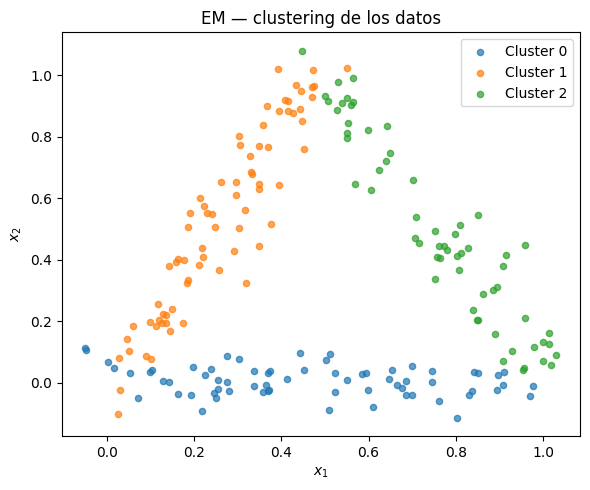

In [7]:
em = EM(k=3)
em.fit(X)
labels_em = em.predict(X)

colors = ['tab:blue', 'tab:orange', 'tab:green']

fig, ax = plt.subplots(figsize=(6, 5))
for j in range(em.k):
    mask = labels_em == j
    ax.scatter(X[mask, 0], X[mask, 1], s=20, alpha=0.7, color=colors[j], label=f'Cluster {j}')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('EM — clustering de los datos')
ax.legend()
plt.tight_layout()
plt.show()

El resultado es notablemente mejor que K-Means. Los tres clusters quedan perfectamente alineados con los tres lados del triángulo: el azul captura la base horizontal, el naranja el lado izquierdo ascendente, y el verde el lado derecho descendente. No se observan errores de asignación en las esquinas, que era el punto débil de K-Means.

Esto confirma el argumento teórico: al aprender $\Sigma_k$ libremente, EM ajusta una gaussiana alargada en la dirección de cada lado, por lo que los puntos en las esquinas quedan correctamente asignados al cluster cuya covarianza está orientada hacia ellos, y no al que tiene el centroide más cercano.

### Fronteras de decisión

Para visualizar cómo EM divide el espacio, se evalúa `predict` sobre una grilla densa y se grafica la región asignada a cada cluster. Las fronteras de decisión de EM son curvas cuádricas (en general hipérbolas o parábolas), porque resultan de igualar las densidades gaussianas de dos clusters: cuando las covarianzas son distintas, esa igualdad da lugar a una ecuación cuadrática en $x$. Esto contrasta con K-Means, cuyas fronteras son siempre rectas.

La razón es geométrica: K-Means asigna cada punto al centroide más cercano, así que la frontera entre dos clusters $j$ y $k$ es el lugar donde $\|x - \mu_j\|^2 = \|x - \mu_k\|^2$. Al expandir esa igualdad, el término $\|x\|^2$ se cancela en ambos lados y queda una ecuación lineal en $x$:

$$2(\mu_k - \mu_j)^T x = \|\mu_k\|^2 - \|\mu_j\|^2$$

Eso es un hiperplano en 2D, la mediatriz del segmento que une los dos centroides. En EM, en cambio, la densidad gaussiana tiene $\Sigma_k^{-1}$ dentro del exponente: si las covarianzas son iguales se cancela y las fronteras también son lineales (ese es el caso LDA), pero si son distintas el término cuadrático en $x$ no desaparece y la frontera se curva.

La forma de estas fronteras también recuerda a las curvas de nivel del SVM con kernel RBF, pero el origen es distinto. En SVM las fronteras curvas vienen de un mapeo implícito a un espacio de alta dimensión, la curvatura la introduce el kernel. Acá no hay kernel: la curvatura emerge directamente de la geometría gaussiana con covarianzas distintas.

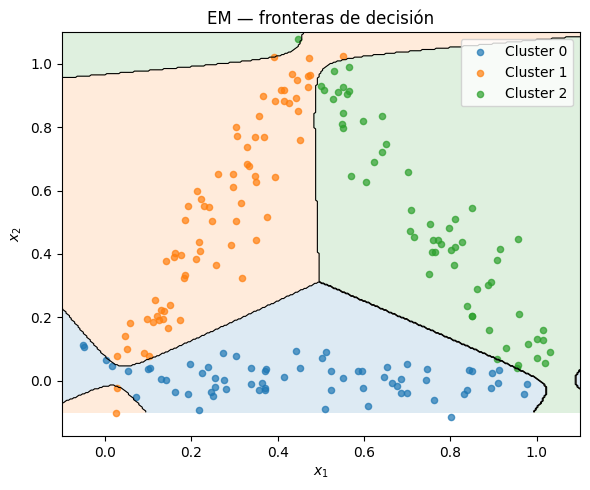

In [8]:
xx, yy = np.meshgrid(np.linspace(-0.1, 1.1, 300), np.linspace(-0.1, 1.1, 300))
grid = np.column_stack([xx.ravel(), yy.ravel()])
Z = em.predict(grid).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(6, 5))
ax.contourf(xx, yy, Z, levels=[-0.5, 0.5, 1.5, 2.5], alpha=0.15, colors=colors)
ax.contour(xx, yy, Z, levels=[-0.5, 0.5, 1.5, 2.5], colors='k', linewidths=0.8)
for j in range(em.k):
    mask = labels_em == j
    ax.scatter(X[mask, 0], X[mask, 1], s=20, alpha=0.7, color=colors[j], label=f'Cluster {j}')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('EM — fronteras de decisión')
ax.legend()
plt.tight_layout()
plt.show()

El gráfico confirma todo lo que se anticipó. Las tres regiones están correctamente orientadas: azul cubre la base horizontal, naranja el lado izquierdo, verde el lado derecho. Las fronteras son curvas, se ve especialmente en la esquina inferior izquierda, donde la frontera entre naranja y azul describe una curva pronunciada en lugar de una recta, y en la esquina superior donde se juntan los tres clusters.

Esa curvatura en las esquinas es exactamente lo que permite a EM hacer lo que K-Means no podía: en las esquinas del triángulo, donde dos lados se encuentran, K-Means trazaría una recta que inevitablemente asignaría mal algunos puntos. EM, en cambio, curva la frontera para que siga la forma de las gaussianas aprendidas, capturando correctamente la transición entre un lado y el otro.

### Sensibilidad a la inicialización



#### Experimento 1: distintas semillas

Se corre EM 8 veces con distintas semillas para ver si la inicialización aleatoria afecta el resultado final.

Semilla 0: Convergió en 34 iteraciones (Δlog-lik = 7.21e-05)
Semilla 1: Convergió en 29 iteraciones (Δlog-lik = 5.27e-05)
Semilla 2: Convergió en 33 iteraciones (Δlog-lik = 5.77e-05)
Semilla 3: Convergió en 27 iteraciones (Δlog-lik = 5.54e-05)
Semilla 4: Convergió en 28 iteraciones (Δlog-lik = 6.55e-05)
Semilla 5: Convergió en 31 iteraciones (Δlog-lik = 4.06e-05)
Semilla 6: Convergió en 29 iteraciones (Δlog-lik = 6.70e-05)
Semilla 7: Convergió en 29 iteraciones (Δlog-lik = 7.72e-05)


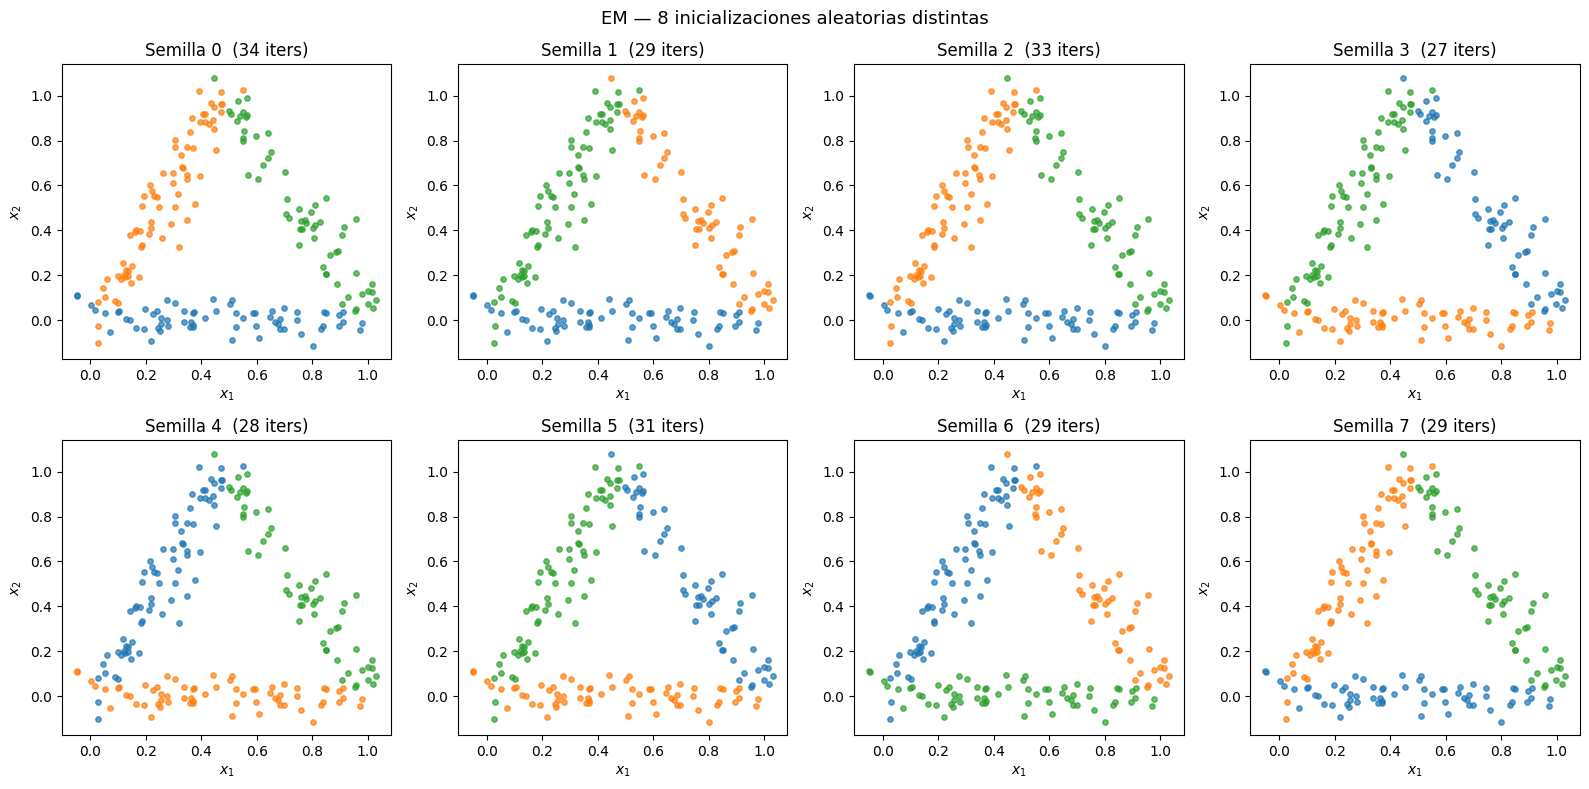

In [9]:
n_runs = 8
seeds = range(n_runs)
colors = ['tab:blue', 'tab:orange', 'tab:green']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for i, seed in enumerate(seeds):
    em_i = EM(k=3, random_state=seed)
    print(f'Semilla {seed}:', end=' ')
    em_i.fit(X)
    labels_i = em_i.predict(X)

    ax = axes[i]
    for j in range(em_i.k):
        mask = labels_i == j
        ax.scatter(X[mask, 0], X[mask, 1], s=15, alpha=0.7, color=colors[j])
    ax.set_title(f'Semilla {seed}  ({em_i.n_iter_} iters)')
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')

plt.suptitle('EM — 8 inicializaciones aleatorias distintas', fontsize=13)
plt.tight_layout()
plt.show()

Las 8 inicializaciones convergen al mismo resultado. Esto muestra que en este dataset la inicialización aleatoria de los centroides es genuinamente robusta: no importa de dónde arranquen los $\mu_k$, EM siempre encuentra la misma solución.

La razón es que los tres lados del triángulo están bien separados respecto al ruido ($\sigma = 0.05$). Cuando los centroides caen al azar en los datos, incluso si dos o tres quedan en el mismo lado, el paso de Expectation distribuye las responsabilidades de forma que en pocas iteraciones los centroides se repelen y cada uno migra hacia un lado distinto. La gran separación entre los grupos hace que esa migración sea estable y no quede atrapada a mitad de camino.

Dicho esto, la robustez no está garantizada en general, depende de la geometría del problema. A continuación se prueban dos casos de inicialización explícita para entender mejor los límites: uno favorable (los centroides de K-Means, que ya están bien ubicados) y uno adverso (tres puntos casi superpuestos cerca del vértice).

#### Experimento 2: inicialización con los centroides de K-Means

Una pregunta natural es qué pasa si en lugar de inicializar aleatoriamente, se le pasan a EM los centroides que encontró K-Means. En principio, K-Means ya ubicó un centroide por lado (con los errores de asignación en las esquinas que se documentaron), así que EM debería partir de una posición razonable. La pregunta es si eso lo lleva al mismo resultado o lo atrapa en un óptimo local distinto, y si converge más rápido al partir de ahí.

Convergió en 38 iteraciones (Δlog-lik = 5.21e-05)


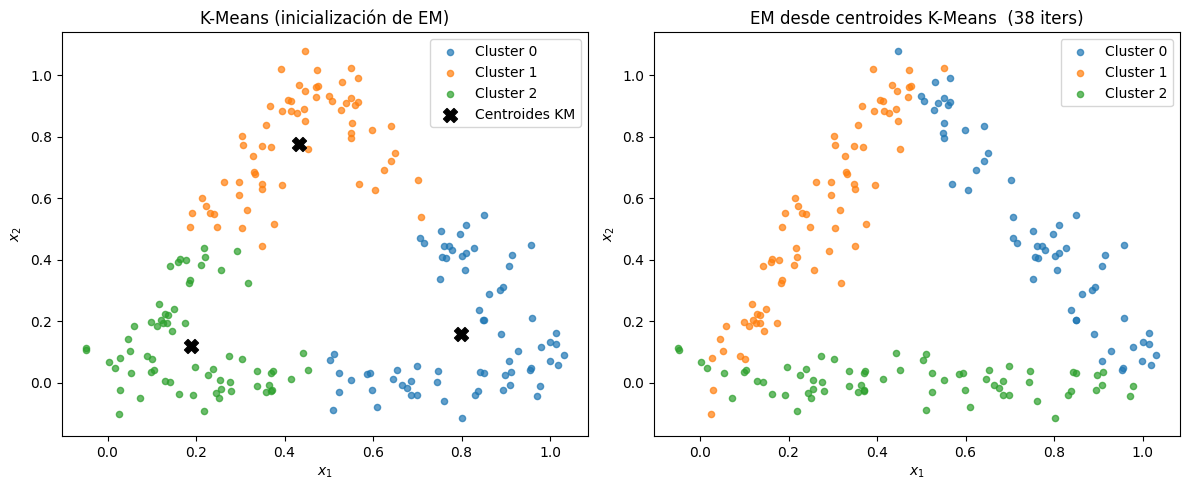

In [10]:
em_km_init = EM(k=3)
em_km_init.fit(X, init_mu=km.centroids)
labels_km_init = em_km_init.predict(X)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Resultado K-Means (punto de partida)
ax = axes[0]
for j in range(km.k):
    mask = labels_km == j
    ax.scatter(X[mask, 0], X[mask, 1], s=20, alpha=0.7, color=colors[j], label=f'Cluster {j}')
ax.scatter(km.centroids[:, 0], km.centroids[:, 1], s=100, marker='X', color='black', zorder=5, label='Centroides KM')
ax.set_title('K-Means (inicialización de EM)')
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.legend()

# EM inicializado con centroides de K-Means
ax = axes[1]
for j in range(em_km_init.k):
    mask = labels_km_init == j
    ax.scatter(X[mask, 0], X[mask, 1], s=20, alpha=0.7, color=colors[j], label=f'Cluster {j}')
ax.set_title(f'EM desde centroides K-Means  ({em_km_init.n_iter_} iters)')
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.legend()

plt.tight_layout()
plt.show()

El resultado geométrico es idéntico al EM con inicialización aleatoria, misma partición de los tres lados, misma calidad de fronteras. Sin embargo, converge en más iteraciones que la mayoría de las semillas aleatorias (~38 vs. 27–34). Eso parece contraintuitivo pero tiene una explicación directa: K-Means dejó las esquinas mal asignadas (puntos donde dos lados se tocan), y esas asignaciones duras se traducen en centroides que están corridos respecto al centro real de cada segmento. En el paso de Expectation del primer ciclo, las responsabilidades suaves de EM ven esa imprecisión y comienzan a redistribuir puntos, lo que mueve los centroides más que si hubieran arrancado desde un punto aleatorio bien posicionado. EM tiene que "deshacer" primero el sesgo heredado de K-Means antes de converger.

El experimento confirma que usar K-Means como warm-start no garantiza acelerar EM, y que en este dataset la inicialización tiene poco peso: la geometría fuertemente separada permite convergencia robusta desde casi cualquier punto de partida.

#### Experimento 3: inicialización con 3 puntos consecutivos (caso adverso)

El peor caso imaginable para la inicialización es arrancar con los tres centroides casi en el mismo lugar. Para probarlo, se toman 3 puntos consecutivos del dataset que caigan cerca del vértice superior del triángulo, una zona donde los tres lados se juntan. Los tres centroides iniciales quedan así casi superpuestos, lo más lejos posible de la configuración ideal.

Convergió en 40 iteraciones (Δlog-lik = 5.94e-05)


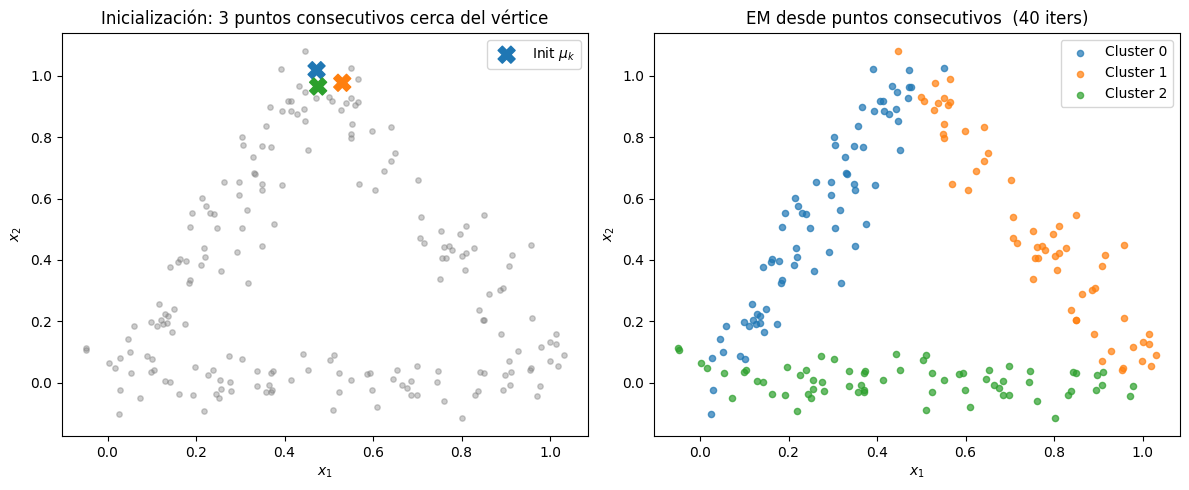

In [11]:
# Buscar puntos cerca del vértice superior (x1 ~ 0.5, x2 ~ 1.0)
apex_region = np.argsort(np.linalg.norm(X - np.array([0.5, 1.0]), axis=1))
init_consecutive = X[apex_region[:3]]

em_consec = EM(k=3)
em_consec.fit(X, init_mu=init_consecutive)
labels_consec = em_consec.predict(X)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Mostrar la inicialización
ax = axes[0]
ax.scatter(X[:, 0], X[:, 1], s=15, alpha=0.4, color='gray')
ax.scatter(init_consecutive[:, 0], init_consecutive[:, 1], s=150, marker='X',
           color=['tab:blue', 'tab:orange', 'tab:green'], zorder=5, label='Init $\\mu_k$')
ax.set_title('Inicialización: 3 puntos consecutivos cerca del vértice')
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.legend()

# Resultado final
ax = axes[1]
for j in range(em_consec.k):
    mask = labels_consec == j
    ax.scatter(X[mask, 0], X[mask, 1], s=20, alpha=0.7, color=colors[j], label=f'Cluster {j}')
ax.set_title(f'EM desde puntos consecutivos  ({em_consec.n_iter_} iters)')
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.legend()

plt.tight_layout()
plt.show()

Sorprendentemente, tampoco se rompe. Incluso arrancando con los tres centroides casi superpuestos en el vértice, EM encuentra la solución correcta en 40 iteraciones, algo más que en las inicializaciones aleatorias (27–34), pero llega al mismo resultado.

El mecanismo es el siguiente: cuando los tres $\mu_k$ están superpuestos, en el primer Expectation-step todos los puntos del dataset reciben responsabilidades casi iguales ($r_{ik} \approx 1/3$) de los tres clusters. En el primer paso de Maximization, los tres centroides se desplazan hacia el promedio ponderado de todos los puntos, es decir, al centroide global del dataset. Desde ahí, cualquier pequeña asimetría numérica rompe la simetría perfecta y los centroides empiezan a separarse. Como los tres lados están tan alejados entre sí, esa separación es suficiente para que en pocas iteraciones cada centroide migre hacia un lado distinto.


## Inciso D: PCA


El objetivo de este inciso es aprender una recta representativa para cada cluster, y con esas tres rectas reconstruir el triángulo completo. El algoritmo que hace eso es **PCA** (*Principal Component Analysis*).

### ¿Qué hace PCA?

La idea central es simple: dado un conjunto de puntos, PCA encuentra la dirección en la que esos puntos están más dispersos, es decir, la dirección de máxima varianza.

Geométricamente, si se tiene una nube de puntos alargada (como los puntos de un lado del triángulo), proyectarla sobre distintas rectas da resultados muy distintos: sobre algunas rectas la proyección queda muy esparcida, sobre otras queda aplastada. PCA elige la recta donde la proyección es más esparcida, que es exactamente el eje mayor de la nube.

### La conexión con Procesos Estocásticos: Karhunen-Loève (a chequear)

Esto es exactamente lo que se vio en Procesos Estocásticos bajo el nombre de descomposición de Karhunen-Loève: descomponer una señal aleatoria en modos ortogonales ordenados por energía.

El procedimiento formal es armar la matriz de covarianza de los datos:

$$C = \frac{1}{N} \sum_{i=1}^N (x_i - \mu)(x_i - \mu)^T$$

Y calcular sus autovectores y autovalores. Los autovectores de $C$ son las direcciones principales del conjunto de puntos, y los autovalores $\lambda_k$ cuantifican cuánta varianza hay en cada dirección. El autovector con el mayor autovalor es la dirección de máxima varianza: eso es el primer componente principal.

### Por qué funciona para el manifold

Para un cluster del triángulo, por ejemplo el lado horizontal, la situación es:

- Los puntos varían mucho a lo largo de ese lado → $\lambda_1$ grande.
- Los puntos varían poco en la dirección perpendicular (solo el ruido de $0.05$) → $\lambda_2 \approx 0$.

El primer autovector apunta exactamente en la dirección del lado. Proyectar un punto sobre ese autovector (`transform` con $k=1$) da su coordenada a lo largo de la recta, y volver al espacio original (`inverse_transform`) da el punto más cercano sobre esa recta, es decir, la reconstrucción del manifold.

### Por qué se necesita un PCA *por cluster*

Si se aplica PCA a todos los 200 puntos juntos, la dirección de máxima varianza apunta vagamente en diagonal (promedia las tres orientaciones del triángulo) y no sirve para reconstruir ningún lado. Por eso se utilliza el **PCA condicional**, primero se separa los datos por cluster con EM (que aprendió qué puntos pertenecen a cada lado), y luego  se aplica un PCA independiente a cada grupo. Así, cada PCA ve solo una nube alargada en una dirección y puede identificarla correctamente.


### Implementación de PCA

La implementación sigue directamente la teoría. A continuación se describe qué hace cada método.

**`fit(X)`: aprende la dirección del cluster**

Se centra la nube restando su media $\mu$ y se arma la matriz de covarianza $C = \frac{1}{N} X_c^T X_c$. En 2D, $C$ es una matriz $2 \times 2$ que codifica la forma de la nube: si los puntos están distribuidos a lo largo de una diagonal, $C$ refleja esa elongación. Luego se diagonaliza $C$ con `eigh` (versión de `eig` para matrices simétricas, numéricamente más estable), obteniendo dos autovectores ortogonales y sus autovalores $\lambda_1 \geq \lambda_2$. El autovector asociado al autovalor más grande es la dirección de máxima varianza, la "dirección larga" de la nube.

**`transform(X, k)`: proyecta sobre la recta**

Dado el autovector principal $v_1$, proyectar un punto $x$ sobre la recta es un producto interno: $(x - \mu) \cdot v_1$. El resultado es un escalar (para $k=1$): la coordenada del punto a lo largo de la dirección principal.

**`inverse_transform(U)`: retorna al espacio original**

Dado un escalar $u$ (coordenada sobre la recta), el punto reconstruido es $\hat{x} = u \cdot v_1 + \mu$. Geométricamente, es el pie de la perpendicular desde el punto original hasta la recta, es decir, el punto del manifold más cercano a $x$.

**`fit_transform(X, k)`: optimización**

Que encadena `fit` y `transform` en un solo paso.


In [12]:
class PCA:
    def __init__(self):
        self.mu = None
        self.components = None
        self.eigvals = None

    def fit(self, X):
        self.mu = X.mean(axis=0)
        Xc = X - self.mu
        C = (Xc.T @ Xc) / len(X)
        eigvals, eigvecs = np.linalg.eigh(C)
        idx = np.argsort(eigvals)[::-1]
        self.eigvals = eigvals[idx]
        self.components = eigvecs[:, idx]  # columnas son autovectores
        return self

    def transform(self, X, k):
        return (X - self.mu) @ self.components[:, :k]

    def inverse_transform(self, U):
        k = U.shape[1]
        return U @ self.components[:, :k].T + self.mu

    def fit_transform(self, X, k):
        self.fit(X)
        return self.transform(X, k)

### PCA por cluster

Se utiliza el clustering obtenido por EM para separar los datos en tres subconjuntos, uno por cluster, y se entrena un PCA independiente sobre cada uno. Luego se calculan los valores mínimo y máximo de la proyección de cada cluster sobre su dirección principal, que definen los extremos de la recta que aproxima ese lado del triángulo.

In [13]:
pcas = []
for j in range(em.k):
    mask = labels_em == j
    pca_j = PCA()
    pca_j.fit(X[mask])
    pcas.append(pca_j)

for j, pca_j in enumerate(pcas):
    mask = labels_em == j
    proj = pca_j.transform(X[mask], k=1)
    v1 = pca_j.components[:, 0]
    u_min, u_max = proj.min(), proj.max()
    inicio = pca_j.mu + u_min * v1
    fin    = pca_j.mu + u_max * v1
    print(f'Cluster {j}:')
    print(f'  Centro (μ):        ({pca_j.mu[0]:.4f}, {pca_j.mu[1]:.4f})')
    print(f'  Dirección (v₁):    ({v1[0]:.4f}, {v1[1]:.4f})')
    print(f'  Autovalores:       λ₁ = {pca_j.eigvals[0]:.4f},  λ₂ = {pca_j.eigvals[1]:.4f}')
    print(f'  Proyección:        min = {u_min:.4f},  max = {u_max:.4f}')
    print(f'  Extremo inicio:    ({inicio[0]:.4f}, {inicio[1]:.4f})')
    print(f'  Extremo fin:       ({fin[0]:.4f}, {fin[1]:.4f})')
    print()


Cluster 0:
  Centro (μ):        (0.4624, 0.0063)
  Dirección (v₁):    (-0.9988, 0.0480)
  Autovalores:       λ₁ = 0.0781,  λ₂ = 0.0021
  Proyección:        min = -0.5158,  max = 0.5166
  Extremo inicio:    (0.9776, -0.0184)
  Extremo fin:       (-0.0536, 0.0311)

Cluster 1:
  Centro (μ):        (0.2654, 0.5323)
  Dirección (v₁):    (0.3935, 0.9193)
  Autovalores:       λ₁ = 0.1042,  λ₂ = 0.0020
  Proyección:        min = -0.6775,  max = 0.5646
  Extremo inicio:    (-0.0012, -0.0905)
  Extremo fin:       (0.4875, 1.0513)

Cluster 2:
  Centro (μ):        (0.7627, 0.4904)
  Dirección (v₁):    (-0.4741, 0.8805)
  Autovalores:       λ₁ = 0.1123,  λ₂ = 0.0023
  Proyección:        min = -0.5042,  max = 0.6690
  Extremo inicio:    (1.0017, 0.0464)
  Extremo fin:       (0.4455, 1.0794)



Los resultados permiten identificar con precisión qué lado del triángulo captura cada cluster.

**Cluster 0 — base horizontal** ($y \approx 0$): la dirección principal es $v_1 \approx (-1,\, 0.05)$, prácticamente horizontal. Los extremos del segmento son $(0.98,\, 0.00)$ y $(-0.05,\, 0.03)$, que corresponden a los vértices $(1,0)$ y $(0,0)$ del triángulo real.

**Cluster 1 — lado izquierdo** (de $(0,0)$ a $(0.5, 1)$): la dirección principal es $v_1 \approx (0.39,\, 0.92)$, con pendiente positiva pronunciada. Los extremos son $(-0.00,\, -0.09)$ y $(0.49,\, 1.05)$, coincidentes con ambos vértices del lado izquierdo.

**Cluster 2 — lado derecho** (de $(1,0)$ a $(0.5, 1)$): la dirección principal es $v_1 \approx (-0.47,\, 0.88)$, con pendiente positiva pero inclinada hacia la izquierda. Los extremos son $(1.00,\, 0.05)$ y $(0.45,\, 1.08)$, coincidentes con los vértices del lado derecho.

En todos los clusters se observa $\lambda_1 \gg \lambda_2$: casi toda la varianza está concentrada en la dirección principal, y la varianza residual perpendicular corresponde al ruido de amplitud $0.05$ introducido en la generación del dataset. Esto confirma que la estructura del manifold es efectivamente unidimensional dentro de cada cluster: los puntos viven cerca de una recta, no de una elipse.


### Visualización del manifold por rectas

Con los tres PCA entrenados, se reconstruye el manifold como tres segmentos de recta. Para cada cluster se genera una grilla de valores escalares $u$ entre el mínimo y el máximo de la proyección, y se aplica `inverse_transform` para volver al plano:

$$\hat{x}(u) = u \cdot v_1 + \mu, \qquad u \in [u_{\min},\, u_{\max}]$$

**¿Por qué segmentos y no rectas infinitas?**

PCA solo aprende una dirección, la recta como objeto matemático es infinita. Los extremos del segmento no los determina PCA, sino los propios datos: $u_{\min}$ y $u_{\max}$ son la proyección mínima y máxima de los puntos del cluster sobre $v_1$:

$$u_{\min} = \min_{i \in \text{cluster } j} (x_i - \mu)^T v_1, \qquad u_{\max} = \max_{i \in \text{cluster } j} (x_i - \mu)^T v_1$$

Geométricamente, son las coordenadas del punto más atrás y el más adelante a lo largo de la dirección principal. El segmento queda acotado exactamente por el rango de la nube de datos, sin extrapolación más allá de donde hay evidencia. Esto funciona bien porque $U_i \sim \mathcal{U}(0,1)$ garantiza que los datos cubren el largo completo de cada lado: con 200 puntos y ruido pequeño, los extremos de la proyección son aproximaciones precisas de los vértices del triángulo.

Cada recta cubre exactamente el tramo del triángulo que sus puntos ocupan, sin extenderse más allá. El resultado esperado son tres segmentos que, unidos, forman el triángulo recuperado a partir de los datos.

**Análisis cuantitativo de la calidad de reconstrucción**

Más allá de lo visual, es importante medir cuánto se desvió cada recta aprendida respecto al triángulo verdadero. La estrategia es:

1. Generar 500 puntos sobre el triángulo real sin ruido.
2. Para cada punto, calcular su distancia perpendicular a la recta PCA más cercana.
3. Reportar estadísticas: media, máxima, mediana, percentil 95%

Esto da números concretos para evaluar si el PCA funcionó bien o no. El error pequeño significa que las rectas están donde deberían estar; el error grande indicaría un problema. Estos números también son cruciales para el Inciso E (detección de anomalías), porque se necesita saber cuál es el "error típico" para distinguir puntos normales de puntos anómalos.

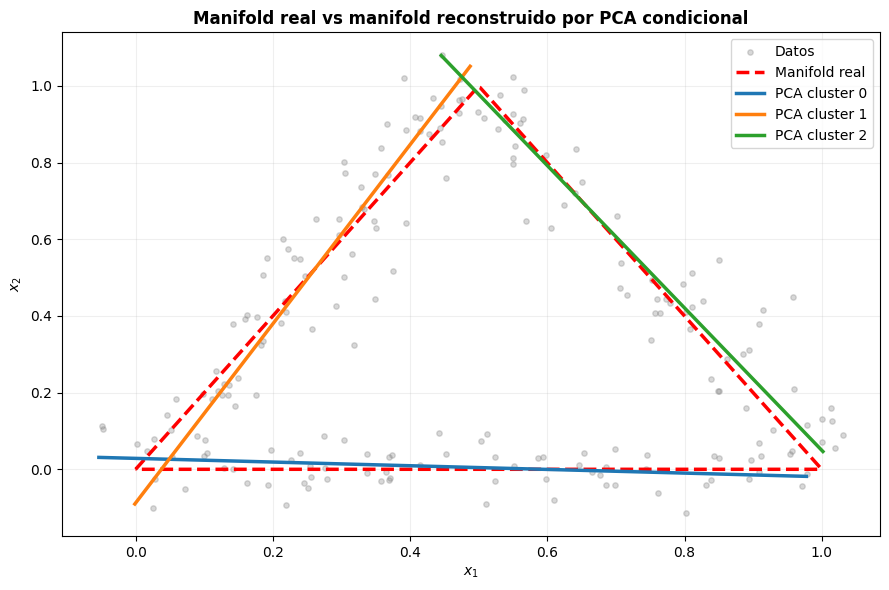

DESVIACIÓN DE LAS RECTAS RECONSTRUIDAS RESPECTO AL MANIFOLD REAL

Cluster 0:
  Puntos analizados del manifold: 178
  Distancia perpendicular media:  0.012702
  Distancia perpendicular máxima: 0.029265
  Distancia perpendicular mediana:0.012254
  Percentil 95%:                  0.026486

Cluster 1:
  Puntos analizados del manifold: 160
  Distancia perpendicular media:  0.015988
  Distancia perpendicular máxima: 0.040188
  Distancia perpendicular mediana:0.015912
  Percentil 95%:                  0.030161

Cluster 2:
  Puntos analizados del manifold: 162
  Distancia perpendicular media:  0.009564
  Distancia perpendicular máxima: 0.022984
  Distancia perpendicular mediana:0.008252
  Percentil 95%:                  0.021343



In [14]:
# Manifold real vs manifold reconstruido por PCA condicional
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(X[:, 0], X[:, 1], s=15, alpha=0.3, color='gray', label='Datos')
ax.plot(M[:, 0], M[:, 1], color='red', linewidth=2.5, linestyle='--', label='Manifold real', zorder=3)

for j, pca_j in enumerate(pcas):
    mask = labels_em == j
    proj = pca_j.transform(X[mask], k=1)
    u_range = np.linspace(proj.min(), proj.max(), 200).reshape(-1, 1)
    line = pca_j.inverse_transform(u_range)
    ax.plot(line[:, 0], line[:, 1], color=colors[j], linewidth=2.5, label=f'PCA cluster {j}', zorder=4)

ax.set_title('Manifold real vs manifold reconstruido por PCA condicional', fontsize=12, fontweight='bold')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# Distancia perpendicular del manifold real a cada recta reconstruida
u_real = np.linspace(0, 1, 500)
M_real = g(u_real)  # Manifold real sin ruido

# Asignar puntos del manifold al cluster más cercano
labels_M = em.predict(M_real)

print("="*75)
print("DESVIACIÓN DE LAS RECTAS RECONSTRUIDAS RESPECTO AL MANIFOLD REAL")
print("="*75)

for j in range(em.k):
    mask_real = labels_M == j
    M_j = M_real[mask_real]

    if len(M_j) == 0:
        continue

    # Centro y dirección principal de la recta
    mu = pcas[j].mu
    v1 = pcas[j].components[:, 0]

    # Proyectar cada punto del manifold sobre la recta
    diff = M_j - mu
    proj_length = diff @ v1  # coordenada sobre la recta
    proj_point = mu + proj_length[:, None] * v1  # punto proyectado sobre la recta

    # Distancia perpendicular: distancia de cada punto a su proyección
    perp_distances = np.linalg.norm(M_j - proj_point, axis=1)

    print(f"\nCluster {j}:")
    print(f"  Puntos analizados del manifold: {len(M_j)}")
    print(f"  Distancia perpendicular media:  {perp_distances.mean():.6f}")
    print(f"  Distancia perpendicular máxima: {perp_distances.max():.6f}")
    print(f"  Distancia perpendicular mediana:{np.median(perp_distances):.6f}")
    print(f"  Percentil 95%:                  {np.percentile(perp_distances, 95):.6f}")

print(f"\n{'='*75}")

El gráfico muestra la comparación entre el manifold real (rojo punteado, generado sin ruido por la función $g(u)$) y el manifold reconstruido por PCA condicional (tres líneas de colores, una por cluster).

**Observación visual:** Las tres rectas reconstruidas están bastante cerca del manifold real, pero hay desviaciones visibles, especialmente en los extremos:

- **Cluster 0 (azul, base):** Alineación razonable, con desvíos en los extremos.
- **Cluster 1 (naranja, lado izquierdo):** Claramente desviado en la zona inferior, particularmente en el extremo izquierdo donde la recta no pasa exactamente por donde debería.
- **Cluster 2 (verde, lado derecho):** También muestra desviaciones en los extremos.

**Análisis cuantitativo:** Se midió la distancia perpendicular entre cada recta aprendida y el manifold real (500 puntos sin ruido). Los resultados muestran:

| Cluster | Media | Máxima | Mediana | Percentil 95% |
|---------|-------|--------|---------|---------------|
| **0 (azul)** | 0.0127 | 0.0293 | 0.0123 | 0.0265 |
| **1 (naranja)** | 0.0160 | 0.0402 | 0.0159 | 0.0301 |
| **2 (verde)** | 0.0096 | 0.0230 | 0.0083 | 0.0213 |

Los errores están todos en el rango de 0.009 a 0.040 unidades, lo que es comparablemente pequeño respecto al ruido original de amplitud 0.05. El cluster naranja es el que mayor error presenta (media 0.016), mientras que el verde es el más preciso (media 0.0096).

**Conclusión:** Las rectas capturan adecuadamente la dirección y posición de cada lado del triángulo. Las desviaciones observadas son:
- **Sistemáticas:** el error perpendicular crece en los extremos de cada segmento (donde la asignación de EM es menos precisa en las esquinas)
- **Comparables al ruido:** los errores máximos (~0.04) son del mismo orden que el ruido de los datos

**Nota metodológica.** Este análisis mide la calidad del *modelo*, no la de los datos. Los puntos de entrada son $g(u)$ sin ruido, por lo que el error obtenido cuantifica únicamente cuánto se desplazó la recta aprendida respecto al triángulo verdadero, sin la contribución del ruido $\sigma \cdot Z_i$. Además, la proyección aquí no aplica clipping a los extremos del segmento (la recta se extiende infinitamente), lo que difiere de la implementación del inciso E. En el inciso E, en cambio, la entrada son los datos ruidosos y la proyección satura al segmento finito: el error resultante mide cuánto se desvía cada punto del manifold aprendido, e incluye el ruido de medición como componente dominante.

## Inciso E: Detector de Anomalías

En este inciso el objetivo ya no es "dibujar" el triángulo, sino usar el modelo para decidir si un punto es normal o anómalo.

Se hace lo siguiente:

1. Se arma una grilla de puntos en $[0,1] \times [0,1]$.
2. Cada punto se procesa con EM + PCA condicional.
3. Se mide cuánto se aparta ese punto de la geometría aprendida.
4. Si se aparta poco, se marca como normal.
5. Si se aparta mucho, se marca como anómalo.

---

### ¿Qué significa "reconstruir" un punto?

Reconstruir un punto significa llevarlo al punto más cercano de la recta principal del cluster al que pertenece.

- Punto original: $x$
- Punto reconstruido: $\hat{x}$

La idea es separar:

- **componente útil** (sobre la recta del manifold local),
- **componente de desvío/ruido** (perpendicular a esa recta).

Es exactamente la lógica "señal + ruido":

$$
x = \hat{x} + r
$$

con $r = x - \hat{x}$ como residuo.

---

### Pasos de la reconstrucción (PCA con $k=1$)

En este TP, para detección de anomalías, siempre se usa PCA con $k=1$ en cada cluster.

1. **Centrar** (restar media del cluster):

$$
x_c = x - \mu
$$

2. **Proyectar** sobre la dirección principal $v_1$:

$$
u = x_c^T v_1 = (x - \mu)^T v_1
$$

3. **Reconstruir en base centrada** usando solo esa componente:

$$
\hat{x}_c = u\,v_1
$$

4. **Descentrar** (sumar la media):

$$
\hat{x} = \hat{x}_c + \mu = \mu + u\,v_1
$$

En el paso 4, si no se suma $\mu$, los puntos reconstruidos quedan mal ubicados (alrededor del origen) y no en la posición real del cluster.

Donde:

- $\mu$: centro del cluster,
- $v_1$: autovector principal,
- $u$: coordenada del punto sobre $v_1$.

---

### ¿Por qué usar $k=1$ y no $k=2$?

- Con **$k=1$** (este TP): se conserva solo la dirección principal del manifold local. La componente perpendicular se descarta y aparece como error de reconstrucción. Eso permite detectar anomalías.
- Con **$k=2$** en 2D: se conservan ambas componentes. Entonces la reconstrucción es prácticamente el mismo punto original (no se mueve), y el error tiende a cero. En ese caso ya no sirve como detector de anomalías geométricas.

---

### Error de reconstrucción y regla de decisión

Se define:

$$
e(x) = \|x - \hat{x}\|^2
$$

Interpretación:

- $e(x)$ chico: punto consistente con el manifold (normal),
- $e(x)$ grande: punto alejado del manifold (posible anomalía).

Con umbral $T$ (en este TP: percentil 95 del error de entrenamiento):

$$
\text{anomalo si } e(x) > T, \qquad \text{normal si } e(x) \le T
$$

Desde el punto de vista estadístico, esta regla puede interpretarse como un test de hipótesis por umbral, donde el estadístico de test es $S(x)=e(x)$. La hipótesis nula es que el punto es compatible con el manifold aprendido ($H_0$), y se rechaza $H_0$ cuando $S(x)>T$. En este inciso, por lo tanto, el foco está en decisión/clasificación; la etapa de estimación de parámetros ocurre antes, durante el entrenamiento de EM y PCA.

### Clasificación de puntos anómalos

Se implementa la reconstrucción condicional sobre las rectas PCA aprendidas. Para cada punto $x$, se proyecta sobre las **tres** rectas (una por cluster) y se calcula su error de reconstrucción en cada una. Luego se toma el menor error:

$$
e(x) = \min_{j \in \{0,1,2\}} \|x - \hat{x}_j\|^2
$$

Este criterio evita huecos artificiales en las zonas de transición entre clusters (que aparecen con asignación dura), y representa mejor el manifold aprendido como unión de tres segmentos.

El umbral $T$ se fija en el **percentil 95** de los errores sobre los datos de entrenamiento. Esto implica que aproximadamente el 5% de los puntos de entrenamiento queda clasificado como anómalo por construcción, definiendo la tasa de falsos positivos esperada en datos normales.

Por último, se evalúa el detector sobre una grilla densa de $250 \times 250$ puntos en $[0,1]^2$, clasificando cada uno como normal ($e(x) \le T$) o anómalo ($e(x) > T$).

In [15]:
# Parametros de segmentos PCA estimados (finito por cluster)
segment_params = []
for j, pca_j in enumerate(pcas):
    mask_j = labels_em == j
    proj_j = pca_j.transform(X[mask_j], k=1).ravel()
    segment_params.append({
        'u_min': proj_j.min(),
        'u_max': proj_j.max(),
        'mu': pca_j.mu.copy(),
        'v1': pca_j.components[:, 0].copy()
    })

# Reconstruccion por mejor segmento PCA (union de 3 tramos finitos)
def reconstruct_conditional(X_in, pca_models, seg_params):
    n = X_in.shape[0]
    best_err2 = np.full(n, np.inf)
    best_rec = np.zeros_like(X_in, dtype=float)
    best_labels = np.full(n, -1, dtype=int)

    for j, pca_j in enumerate(pca_models):
        mu = seg_params[j]['mu']
        v1 = seg_params[j]['v1']
        u_min = seg_params[j]['u_min']
        u_max = seg_params[j]['u_max']

        # Proyeccion sobre v1 y saturacion al segmento [u_min, u_max]
        U_j = ((X_in - mu) @ v1).reshape(-1, 1)
        U_j = np.clip(U_j, u_min, u_max)

        # Punto reconstruido sobre el tramo finito j
        X_rec_j = pca_j.inverse_transform(U_j)
        err2_j = np.sum((X_in - X_rec_j) ** 2, axis=1)

        improve = err2_j < best_err2
        best_err2[improve] = err2_j[improve]
        best_rec[improve] = X_rec_j[improve]
        best_labels[improve] = j

    return best_rec, best_labels, best_err2

# Error de reconstruccion en entrenamiento
X_rec_train, labels_train, err2_train = reconstruct_conditional(X, pcas, segment_params)

# Umbral: percentil 95 del error en entrenamiento
threshold = np.percentile(err2_train, 95)

# Grilla en [0,1] x [0,1]
grid_n = 250
xg = np.linspace(0, 1, grid_n)
yg = np.linspace(0, 1, grid_n)
xx, yy = np.meshgrid(xg, yg)
G = np.column_stack([xx.ravel(), yy.ravel()])

# Reconstruccion y clasificacion de anomalias en la grilla
G_rec, labels_G, err2_G = reconstruct_conditional(G, pcas, segment_params)
is_anomaly = err2_G > threshold
is_normal = ~is_anomaly

print('=' * 75)
print('DETECTOR DE ANOMALIAS (PCA CONDICIONAL)')
print('=' * 75)
print(f'Umbral (percentil 95 train): {threshold:.6f}')
print(f'Tamanio de grilla: {grid_n} x {grid_n} = {G.shape[0]} puntos')
print(f'Puntos no anomalos: {is_normal.sum()}')
print(f'Puntos anomalos:    {is_anomaly.sum()}')
print(f'Proporcion anomala: {is_anomaly.mean():.3f}')

DETECTOR DE ANOMALIAS (PCA CONDICIONAL)
Umbral (percentil 95 train): 0.007724
Tamanio de grilla: 250 x 250 = 62500 puntos
Puntos no anomalos: 26531
Puntos anomalos:    35969
Proporcion anomala: 0.576


El umbral obtenido es $T = 0.007724$, que equivale a una distancia euclidiana de $\sqrt{T} \approx 0.088$ unidades. Cualquier punto ubicado a más de ~0.088 unidades del manifold aprendido es clasificado como anómalo.

La proporción anómala en la grilla ($57.6\%$) puede interpretarse geométricamente. El detector no clasifica una recta de espesor cero, sino una **franja** de ancho $\approx 2\sqrt{T} \approx 0.176$ a lo largo de cada segmento. El perímetro del manifold aprendido se obtiene directamente del rango de proyección de cada cluster (que equivale a la longitud del segmento, dado que $v_1$ es unitario):

| Cluster | $u_{\max} - u_{\min}$ (longitud) |
|---------|----------------------------------|
| 0 (base) | $0.5166 - (-0.5158) = 1.032$ |
| 1 (lado izq.) | $0.5646 - (-0.6775) = 1.242$ |
| 2 (lado der.) | $0.6690 - (-0.5042) = 1.173$ |
| **Total** | **3.447 unidades** |

El área esperada de la franja normal sería $3.447 \times 0.176 \approx 0.61$ en un cuadrado de área unitaria (~61% normal). El valor efectivo obtenido ($42.4\%$ normal) es notablemente menor porque en las esquinas del triángulo la asignación de EM introduce errores: puntos próximos a la intersección de dos lados quedan asignados al PCA de un único cluster, cuya dirección principal no los representa bien, elevando su error de reconstrucción y achicando la franja efectiva en esas zonas.

### Visualización del manifold reconstruido

Se grafican los puntos **no anómalos** de la grilla, coloreados según el cluster PCA que los reconstruye con menor error. La región resultante representa el manifold aprendido: tres franjas orientadas que forman el triángulo.

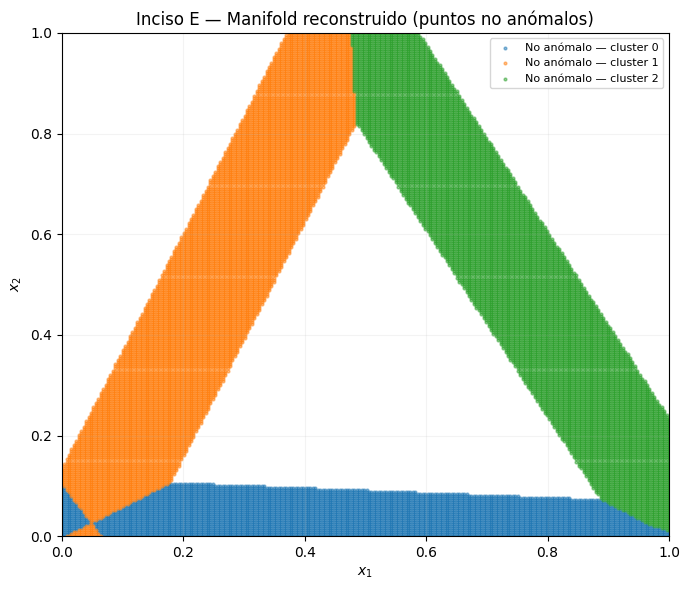

In [ ]:
cluster_colors = ['tab:blue', 'tab:orange', 'tab:green']

fig, ax = plt.subplots(figsize=(7, 6))

for j in range(em.k):
    mask_j = is_normal & (labels_G == j)
    ax.scatter(
        G[mask_j, 0], G[mask_j, 1],
        s=4, alpha=0.5, color=cluster_colors[j],
        label=f'No anómalo — cluster {j}'
    )

for j in range(em.k):
    mask_j = labels_em == j
    ax.scatter(
        X[mask_j, 0], X[mask_j, 1],
        s=25, alpha=0.9, color=cluster_colors[j],
        edgecolors='black', linewidths=0.4, zorder=5,
        label=f'Train — cluster {j}' if j == 0 else '_nolegend_'
    )

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('Inciso E — Manifold reconstruido (puntos no anómalos)')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.15)
plt.tight_layout()
plt.show()


### Sensibilidad al umbral

La elección de $T$ en el percentil 95 no es la única opción posible. Para entender qué implicaciones tiene ese criterio, se repite la clasificación con cuatro percentiles distintos: 90, 95, 99 y 99.5. El objetivo es observar cómo varía la franja de detección y evaluar si el comportamiento es suave y monótono (lo deseable) o si hay saltos abruptos que indiquen inestabilidad.

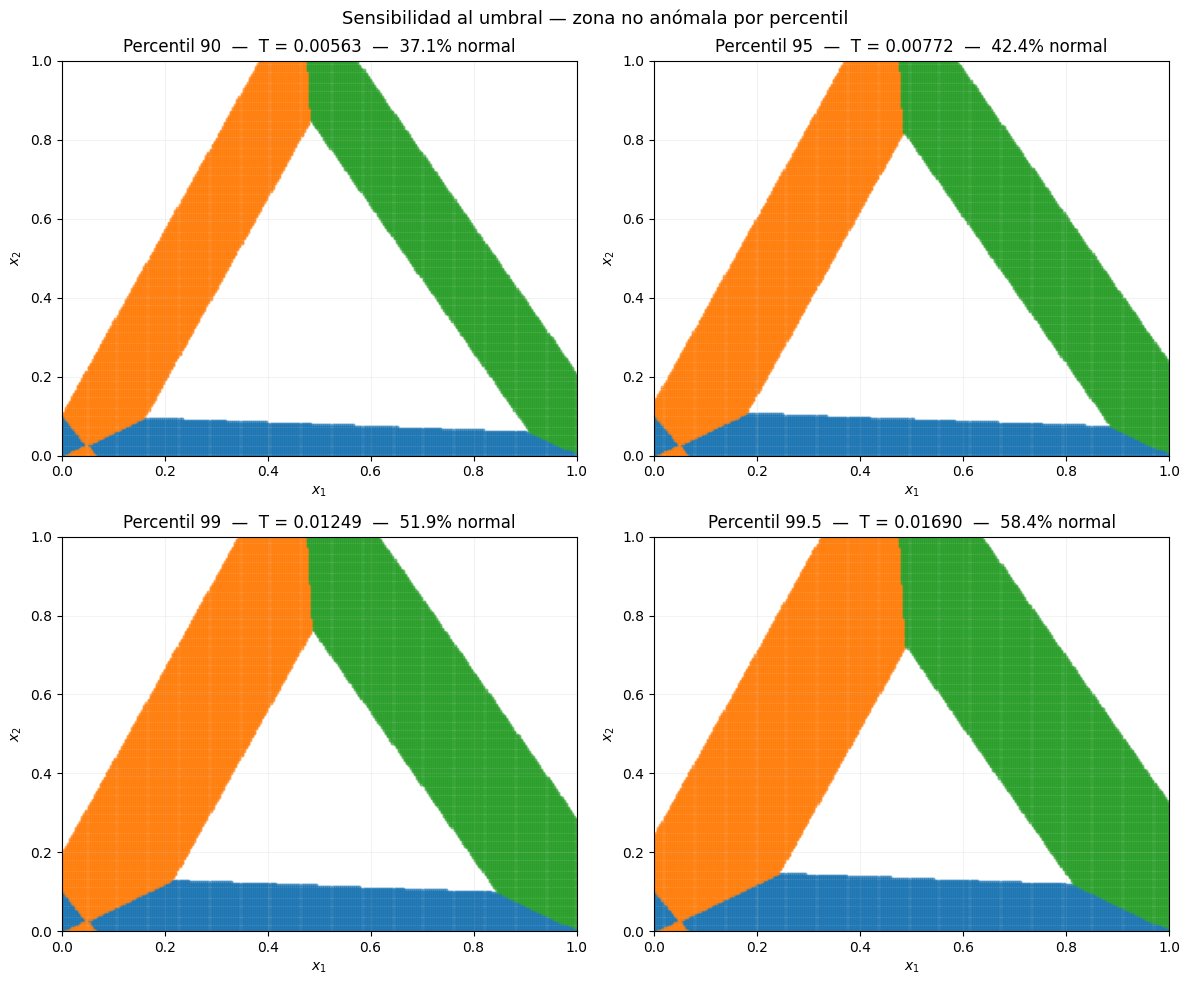

In [ ]:
percentiles = [90, 95, 99, 99.5]
cluster_colors = ['tab:blue', 'tab:orange', 'tab:green']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for ax, p in zip(axes, percentiles):
    T_p = np.percentile(err2_train, p)
    normal_p = err2_G <= T_p

    for j in range(em.k):
        mask_j = normal_p & (labels_G == j)
        ax.scatter(G[mask_j, 0], G[mask_j, 1], s=4, alpha=0.5, color=cluster_colors[j])

    for j in range(em.k):
        mask_j = labels_em == j
        ax.scatter(
            X[mask_j, 0], X[mask_j, 1],
            s=20, alpha=0.9, color=cluster_colors[j],
            edgecolors='black', linewidths=0.4, zorder=5
        )

    proporcion_normal = normal_p.mean()
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_title(f'Percentil {p}  —  T = {T_p:.5f}  —  {proporcion_normal:.1%} normal')
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.grid(True, alpha=0.15)

plt.suptitle('Sensibilidad al umbral — zona no anómala por percentil', fontsize=13)
plt.tight_layout()
plt.show()



El gráfico anterior muestra que el comportamiento del detector cambia cualitativamente entre percentiles. De P90 a P99, el umbral $T$ se más que duplica (de 0.00563 a 0.01249) aunque solo se incorpora un 9% adicional de puntos de entrenamiento. Esto no es lineal y la causa es debido a la estadística.

> El error de reconstrucción es una distribución $\chi^2(1)$

Para entender por qué, hay que seguir la cadena completa desde la generación de los datos hasta el error de reconstrucción.

Los datos se generaron como:

$$x_i = g(u_i) + \sigma Z_i, \qquad Z_i \sim \mathcal{N}(0, I_2)$$

El ruido $Z_i$ es un vector 2D con componentes independientes. Cuando se aplica PCA con $k=1$ sobre un cluster, se aprende una dirección principal $v_1$ (a lo largo del segmento) y se descarta la dirección perpendicular $v_\perp$. El ruido $Z_i$ puede descomponerse en dos componentes ortogonales:

$$Z_i = \underbrace{(Z_i \cdot v_1)\, v_1}_{Z_{\parallel,i} \text{ — a lo largo del segmento}} + \underbrace{(Z_i \cdot v_\perp)\, v_\perp}_{Z_{\perp,i} \text{ — perpendicular al segmento}}$$

La reconstrucción PCA proyecta el punto sobre $v_1$ y reconstruye solo esa componente. El punto reconstruido queda como:

$$\hat{x}_i = g(u_i) + \sigma Z_{\parallel,i}$$

La componente paralela queda capturada en la reconstrucción. La componente perpendicular desaparece. El error es exactamente lo que se pierde:

$$e_i = \|x_i - \hat{x}_i\|^2 = \|\sigma Z_{\perp,i}\|^2 = \sigma^2 Z_{\perp,i}^2$$

Como $Z_i \sim \mathcal{N}(0, I_2)$, cualquier proyección lineal sobre un vector unitario es $\mathcal{N}(0,1)$. En particular, $Z_{\perp,i} \sim \mathcal{N}(0,1)$. Y el cuadrado de una normal estándar sigue una distribución **chi-cuadrado** con 1 grado de libertad:

$$\frac{e_i}{\sigma^2} = Z_{\perp,i}^2 \sim \chi^2(1)$$

La $\chi^2(1)$ tiene cola derecha pesada por construcción. La distribución $\chi^2(1)$ es simplemente la distribución de $X^2$ con $X \sim \mathcal{N}(0,1)$. La gaussiana es simétrica, pero al elevar al cuadrado los valores grandes se amplifican fuertemente: si $X = 3$, el error es $9\times$ más grande que si $X=1$. Eso concentra la mayor parte de la masa cerca del cero pero estira la cola hacia la derecha de forma pronunciada. En números concretos:

| Percentil | Cuantil $\chi^2(1)$ | Múltiplo de la mediana |
|-----------|--------------------|-----------------------|
| P50 (mediana) | 0.45 | $1\times$ |
| P90 | 2.71 | $6\times$ |
| P99 | 6.63 | $14.7\times$ |

Eso explica directamente el salto observado en $T$: no hay "más puntos malos" entre P90 y P99. Son simplemente los puntos de entrenamiento que tuvieron el mayor ruido perpendicular, algo completamente esperable con $N=200$ muestras gaussianas. Los 2 puntos que quedan entre P99 y P100 no son anomalías del modelo, son los 2 puntos del dataset que por azar tuvieron $|Z_\perp| \approx 2.5\,\sigma$.

De esto se desprende la elección del percentil operativo:

- **P90–P95:** el umbral $T$ corresponde a cuantiles centrales de la $\chi^2(1)$ ($\approx 2.7$–$3.8$). El ancho de franja $2\sqrt{T} \approx 0.15$–$0.18$ es de $\approx 3$–$3.5\,\sigma$, directamente trazable al ruido de medición.
- **P99 en adelante:** se entra en la cola extrema de la $\chi^2(1)$. El umbral ya no refleja el ruido típico sino los eventos raros de la distribución gaussiana. La franja crece sin justificación física.

Para confirmar esta relación cuantitativamente, a continuación se calcula el ancho de franja $2\sqrt{T}$ para distintos percentiles y se compara con los cuantiles teóricos de $\sigma^2 \cdot \chi^2(1)$.


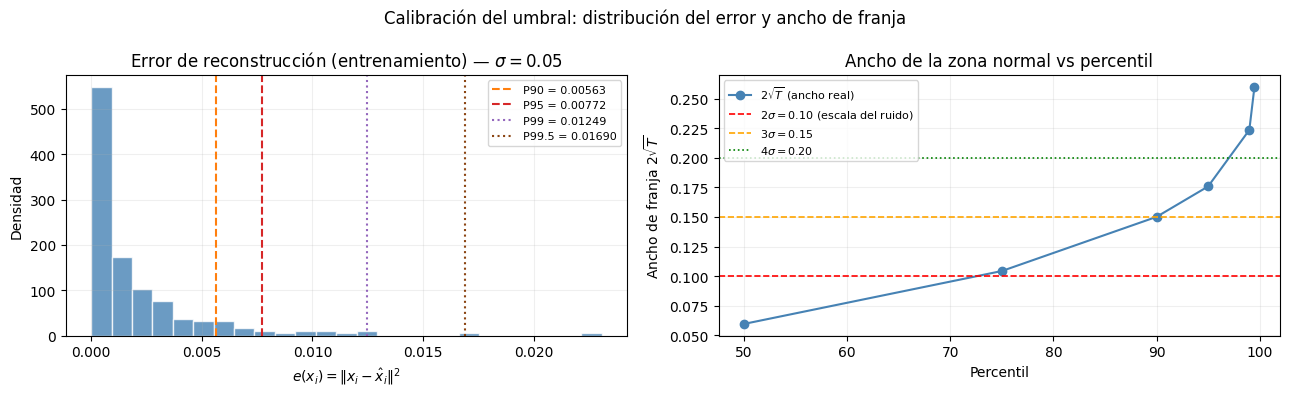

 Percentil           T    semiancho √T     ancho 2√T     ancho/σ
──────────────────────────────────────────────────────────────
        50     0.00089          0.0298        0.0597         1.2σ
        75     0.00272          0.0522        0.1043         2.1σ
        90     0.00563          0.0750        0.1501         3.0σ
        95     0.00772          0.0879        0.1758         3.5σ
        99     0.01249          0.1117        0.2235         4.5σ
      99.5     0.01690          0.1300        0.2600         5.2σ


In [19]:

sigma = 0.05
percentiles_ext = [50, 75, 90, 95, 99, 99.5]
Ts_ext = {p: np.percentile(err2_train, p) for p in percentiles_ext}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histograma del error de reconstrucción en entrenamiento
ax = axes[0]
ax.hist(err2_train, bins=25, color='steelblue', edgecolor='white', alpha=0.8, density=True)
vline_colors = ['tab:orange', 'tab:red', 'tab:purple', 'saddlebrown']
for p, ls, c in zip([90, 95, 99, 99.5], ['--', '--', ':', ':'], vline_colors):
    ax.axvline(Ts_ext[p], linestyle=ls, linewidth=1.5, color=c, label=f'P{p} = {Ts_ext[p]:.5f}')
ax.set_xlabel('$e(x_i) = \\|x_i - \\hat{x}_i\\|^2$')
ax.set_ylabel('Densidad')
ax.set_title(f'Error de reconstrucción (entrenamiento) — $\\sigma = {sigma}$')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.2)

# Ancho de franja 2√T vs percentil
band_widths = [2 * np.sqrt(Ts_ext[p]) for p in percentiles_ext]

ax = axes[1]
ax.plot(percentiles_ext, band_widths, 'o-', color='steelblue', label='$2\\sqrt{T}$ (ancho real)')
ax.axhline(2 * sigma, color='red',    linestyle='--', linewidth=1.2, label=f'$2\\sigma = {2*sigma:.2f}$ (escala del ruido)')
ax.axhline(3 * sigma, color='orange', linestyle='--', linewidth=1.2, label=f'$3\\sigma = {3*sigma:.2f}$')
ax.axhline(4 * sigma, color='green',  linestyle=':',  linewidth=1.2, label=f'$4\\sigma = {4*sigma:.2f}$')
ax.set_xlabel('Percentil')
ax.set_ylabel('Ancho de franja $2\\sqrt{T}$')
ax.set_title('Ancho de la zona normal vs percentil')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.2)

plt.suptitle('Calibración del umbral: distribución del error y ancho de franja', fontsize=12)
plt.tight_layout()
plt.show()

# Tabla resumen
print(f"{'Percentil':>10}  {'T':>10}  {'semiancho √T':>14}  {'ancho 2√T':>12}  {'ancho/σ':>10}")
print('─' * 62)
for p in percentiles_ext:
    T = Ts_ext[p]
    hw = np.sqrt(T)
    bw = 2 * hw
    print(f"{p:>10}  {T:>10.5f}  {hw:>14.4f}  {bw:>12.4f}  {bw/sigma:>10.1f}σ")


Los resultados numéricos permiten contrastar directamente la hipótesis teórica planteada en la celda anterior. Si el error sigue $e_i \sim \sigma^2 \cdot \chi^2(1)$, el ancho de franja teórico en cada percentil es $2\sigma\sqrt{q_p}$, donde $q_p$ es el cuantil $p$ de la $\chi^2(1)$. Comparando con los valores observados:

| Percentil | $q_p$ ($\chi^2_1$) | Ancho teórico $2\sigma\sqrt{q_p}$ | Ancho observado $2\sqrt{T}$ | Razón obs/teo |
|-----------|--------------------|------------------------------------|------------------------------|---------------|
| P90 | 2.71 | 0.164 | 0.150 | 0.91 |
| P95 | 3.84 | 0.196 | 0.176 | 0.90 |
| P99 | 6.63 | 0.257 | 0.224 | 0.87 |
| P99.5 | 7.88 | 0.280 | 0.260 | 0.93 |

Los valores observados son sistemáticamente un 9–13% menores que los teóricos. Esto es esperable: el modelo teórico asume reconstrucción perfecta sobre una recta infinita, pero la implementación usa segmentos finitos con extremos determinados por los datos de entrenamiento. El clipping en los extremos del segmento recorta levemente el error de los puntos más alejados del centro del cluster, produciendo una distribución con cola ligeramente más corta que la $\chi^2(1)$ pura. A pesar de esto, el patrón es consistente en todos los percentiles, lo que valida la hipótesis: la distribución observada es una versión levemente truncada de $\sigma^2 \cdot \chi^2(1)$, no una distribución con una naturaleza diferente.

#### Elección del umbral: P95

Un umbral $T$ en el percentil $p$ equivale a aceptar como normal todo punto con componente de ruido perpendicular $|Z_\perp| < \sqrt{q_p}$. La siguiente tabla muestra la distancia perpendicular equivalente en unidades de $\sigma$ para cada opción:

| Percentil | $q_p$ | $|Z_\perp|$ equivalente | Interpretación |
|-----------|--------|--------------------------|----------------|
| P90 | 2.71 | $1.65\,\sigma$ | Demasiado estricto — flagea ruido normal frecuente |
| **P95** | **3.84** | $\mathbf{1.96\,\sigma}$ | **Intervalo de confianza 95% gaussiano clásico** |
| P99 | 6.63 | $2.57\,\sigma$ | ~2 puntos de cada 200 llegan aquí por azar |
| P99.5 | 7.88 | $2.81\,\sigma$ | Cola extrema sin justificación física |

El valor $\sqrt{3.84} = 1.96$ no es casual: corresponde exactamente al cuantil $z_{0.975}$ de la distribución normal estándar, i.e., el umbral del intervalo de confianza del 95% bilateral. Un punto ubicado más allá de $\pm 1.96\,\sigma$ perpendicularmente al manifold tiene menos del 5% de probabilidad de ser explicado por ruido de medición bajo el modelo $Z \sim \mathcal{N}(0, I_2)$. Este criterio no requiere calibración adicional: surge directamente del modelo generativo asumido para los datos.

Con P90 (±1.65σ), ~10% de los puntos normales serían flaggeados por el propio ruido del sistema — tasa de falsos positivos inaceptable. Con P99 (±2.57σ), se tolerarían desviaciones que solo ocurren 2 veces cada 200 puntos por pura suerte, confundiendo fluctuaciones estadísticas extremas con anomalías reales.

**P95 es el punto de equilibrio natural**: aplica el mismo criterio de significancia estadística estándar (α = 0.05) que se usa en inferencia clásica, ahora como umbral de detección. El valor $T = 0.00772$ queda fijado para el resto del análisis.

### Limitación fundamental: confianza ciega en el manifold estimado

Todo el detector de anomalías construido en este inciso descansa sobre una suposición implícita: que el manifold aprendido por EM + PCA es una buena aproximación del manifold real. Si esa suposición no se cumple, el detector no identifica anomalías absolutas, sino desviaciones respecto a un modelo sesgado.

En este TP el manifold real es conocido (se construyó explícitamente mediante $g(u)$), y en el inciso D se cuantificó el error de estimación. Ese es un escenario inusual: en la práctica nunca se dispone de la curva subyacente verdadera ni, por lo tanto, del error de estimación del manifold.

Esto plantea una pregunta de fondo: **¿cómo se valida un detector de anomalías cuando no existe verdad de referencia?**

**Estabilidad del modelo.** Si se entrena el pipeline con distinta semilla, distinto $K$ o distinta partición de los datos y el manifold estimado cambia drásticamente, ninguna versión es confiable. Un modelo robusto debe converger a una estructura similar independientemente de la inicialización. Alta sensibilidad a la inicialización es señal de que el manifold no está bien determinado por los datos disponibles.

**Separación de distribuciones.** Se calcula $e(x)$ para puntos que se saben normales (los datos de entrenamiento) y para puntos que se saben claramente anómalos (sintéticos, muy lejos del soporte). Si ambas distribuciones de error se solapan en exceso, el umbral $T$ no tiene poder discriminativo real, independientemente de en qué percentil se fije.

**Sensibilidad al umbral.** Se analizó cómo varía la franja de detección al usar los percentiles 90, 95, 99 y 99.5. El comportamiento fue suave y monótono, con anchos de 3.0σ a 5.2σ, explicado directamente por la distribución $\chi^2(1)$ del error. No se observaron saltos abruptos entre percentiles consecutivos, lo que indica que el umbral operativo P95 no se encuentra en una zona inestable de la distribución. Esta verificación es posible en este TP porque el manifold real es conocido; en problemas reales constituye una validación necesaria antes de fijar $T$.